# NLP: FinBERT Parameter-Efficient Fine-Tuning (rsLoRA)

This notebook performs Parameter-Efficient Fine-Tuning (PEFT) using **Rank-Stabilized LoRA (rsLoRA)** on the `ProsusAI/finbert` model. 

Instead of training all ~109 million parameters (Full Fine-Tuning), rsLoRA freezes the base model and injects trainable rank decomposition matrices into the attention layers. This drastically reduces the computational burden and the final model size on disk (from ~438 MB to just ~1.8 MB) while striving to maintain comparable performance on our 3-class financial sentiment dataset.

**Key Steps:**
1. **Setup & Data:** (Same as previous notebooks) Loading and tokenizing the dataset.
2. **PEFT Configuration:** Wrapping the base FinBERT model with `peft` and enabling `use_rslora=True`.
3. **Training:** Using the Hugging Face `Trainer` to optimize only the newly added LoRA weights.
4. **Evaluation:** Comparing test set metrics against the Full Fine-Tuning approach.
5. **Serialization:** Saving the ultra-lightweight LoRA adapters.

In [1]:
# Install required dependencies including 'peft' for LoRA support
%pip install transformers torch datasets pandas scikit-learn peft accelerate>=1.1.0

Note: you may need to restart the kernel to use updated packages.


## 1. Setup, Data Loading & Tokenization

*Note: This section executes the standard data cleaning, stratified splitting (80/10/10), and tokenization pipeline established in earlier notebooks.*

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

# --- Configuration ---
SEED = 42
MODEL_NAME = "ProsusAI/finbert"
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Data Loading & Cleaning ---
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "sentiment_dataset_expanded.csv"))
df = pd.read_csv(DATA_PATH)

df = df[["text", "sentiment"]].copy()
df["text"] = df["text"].astype(str).str.strip()
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()
df = df.dropna(subset=["text", "sentiment"])
df = df[df["text"] != ""]
df = df[df["sentiment"].isin(LABEL2ID.keys())]
df = df.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True)
df["label"] = df["sentiment"].map(LABEL2ID).astype(int)

# --- Stratified Split ---
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"])

# --- Tokenization ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

train_tok = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True)).map(tokenize_batch, batched=True)
val_tok = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True)).map(tokenize_batch, batched=True)
test_tok = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True)).map(tokenize_batch, batched=True)

cols = ["input_ids", "attention_mask", "label"]
if "token_type_ids" in train_tok.column_names:
    cols.append("token_type_ids")

train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

# Class weights to mitigate any residual class imbalance after dataset rebalancing
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label"].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights: {class_weights}")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/22122 [00:00<?, ? examples/s]

Map:   0%|          | 0/2765 [00:00<?, ? examples/s]

Map:   0%|          | 0/2766 [00:00<?, ? examples/s]

Class weights: [1.16658757 0.93341772 0.93329958]


## 2. Parameter-Efficient Initialization (rsLoRA)

Here is where PEFT diverges from Full Fine-Tuning. We load the base model and wrap it using `get_peft_model` along with our `LoraConfig`.

- **`use_rslora=True`**: Enables Rank-Stabilized LoRA, which scales adapters by `alpha / sqrt(r)` instead of `alpha / r`. This stabilizes learning at higher ranks and allows us to safely increase `r`.
- **`r=16` and broader `target_modules`** (`query`, `key`, `value`, `dense`): more expressive capacity, suitable for the expanded balanced dataset.
- **`modules_to_save=["classifier"]`**: the classification head is fully trained from scratch (FinBERT's original head was pre-trained for its own labels and benefits from full re-training).
- We are still training only a tiny fraction of the total parameters.

In [3]:
from peft import get_peft_model, LoraConfig, TaskType

# 1. Define the rsLoRA Configuration
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,                       # Higher rank: more expressive capacity (safe with rsLoRA)
    lora_alpha=16,              # Scaling factor (rsLoRA scales by alpha/sqrt(r))
    lora_dropout=0.15,          # Slight regularization bump
    bias="none",
    target_modules=["query", "key", "value", "dense"],  # Broader attention coverage
    modules_to_save=["classifier"],  # Fully retrain the classification head
    use_rslora=True,            # Rank-Stabilized LoRA
    inference_mode=False,
)

# 2. Load the base model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

# 3. Wrap the base model with PEFT
model = get_peft_model(model, lora_config)

print(f"Model number of labels: {model.config.num_labels}")
print(f"id2label mapping: {model.config.id2label}")

# 4. Verify the reduction in trainable parameters
print(f"\nParameters: {model.print_trainable_parameters()}")

# Metrics tracking function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Model number of labels: 3
id2label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}
trainable params: 2,681,091 || all params: 112,165,638 || trainable%: 2.3903

Parameters: None


## 3. Training with Label Smoothing + Hugging Face Trainer

We use a custom `LabelSmoothingTrainer` to:

- Apply **label smoothing (ε=0.1)** so the model does not produce overconfident logits, leading to less extreme prediction scores and better calibration on real-world data (e.g. when compared against Alpha Vantage sentiment scores).
- Optionally inject **class weights** for residual class imbalance.

Training hyperparameters:
- **`learning_rate=1e-4`** (lower than the previous `2e-4` because `r=16` and the larger dataset converge more stably with a smaller LR).
- **`warmup_ratio=0.1`** and **`cosine` scheduler** to smooth the optimization trajectory.
- **`num_train_epochs=4`** — slightly more epochs since rsLoRA tends to need more time to fully exploit the expanded data.

In [4]:
class LabelSmoothingTrainer(Trainer):
    """
    Custom Trainer that applies label smoothing and optional class weights
    to the cross-entropy loss.
    """
    def __init__(self, *args, label_smoothing=0.0, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.label_smoothing = label_smoothing
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        weights = (
            self.class_weights.to(outputs.logits.device)
            if self.class_weights is not None
            else None
        )
        loss_fn = nn.CrossEntropyLoss(
            weight=weights,
            label_smoothing=self.label_smoothing,
        )
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

In [5]:
SAVE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "models", "finbert_rslora_finetuned"))

# Define Training Arguments
training_args = TrainingArguments(
    output_dir=SAVE_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=1e-4,                  # Lower LR: more stable with r=16 and larger dataset
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,                  # Slightly more epochs for rsLoRA convergence
    warmup_ratio=0.1,                    # LR warmup for smoother start
    weight_decay=0.01,
    lr_scheduler_type="cosine",          # Smooth cosine decay
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
)

# Initialize the custom Trainer with label smoothing + class weights
trainer = LabelSmoothingTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    label_smoothing=0.1,                 # Reduces overconfidence -> less extreme predictions
    class_weights=class_weights_tensor,  # Set to None to disable
)

# Start training the rsLoRA adapters
print("Starting rsLoRA fine-tuning with label smoothing...")
train_result = trainer.train()
display(train_result)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting rsLoRA fine-tuning with label smoothing...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.688472,0.659663,0.780832,0.784488,0.780832,0.780261
2,0.621104,0.648243,0.796745,0.798825,0.796745,0.796344
3,0.545845,0.647478,0.807957,0.809657,0.807957,0.807585
4,0.523781,0.646809,0.806510,0.807154,0.806510,0.806322


TrainOutput(global_step=2768, training_loss=0.6660846743969558, metrics={'train_runtime': 994.099, 'train_samples_per_second': 89.013, 'train_steps_per_second': 2.784, 'total_flos': 3976511567091840.0, 'train_loss': 0.6660846743969558, 'epoch': 4.0})

## 4. Evaluation on Test Set

We test our PEFT model to ensure we haven't sacrificed predictive accuracy for training efficiency.

Validation metrics:
{'val_loss': 0.6474777460098267, 'val_accuracy': 0.8079566003616636, 'val_precision': 0.8096565653005205, 'val_recall': 0.8079566003616636, 'val_f1': 0.807584646639396, 'val_runtime': 13.068, 'val_samples_per_second': 211.586, 'val_steps_per_second': 3.367, 'epoch': 4.0}

Test metrics:
{'test_loss': 0.6093709468841553, 'test_accuracy': 0.8261026753434563, 'test_precision': 0.8270102117322891, 'test_recall': 0.8261026753434563, 'test_f1': 0.8257253504678309, 'test_runtime': 13.3068, 'test_samples_per_second': 207.863, 'test_steps_per_second': 3.307, 'epoch': 4.0}
CLASSIFICATION REPORT - rsLoRA Fine-Tuning
              precision    recall  f1-score   support

    negative       0.80      0.89      0.84       790
     neutral       0.83      0.80      0.82       988
    positive       0.84      0.80      0.82       988

    accuracy                           0.83      2766
   macro avg       0.83      0.83      0.83      2766
weighted avg       0.83      0.83      0.8

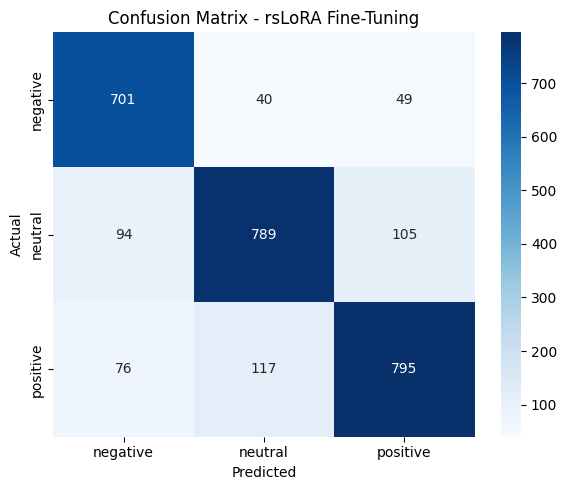

ROC-AUC (weighted OvR): 0.9451


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# 1. Standard Hugging Face Evaluation
val_metrics = trainer.evaluate(eval_dataset=val_tok, metric_key_prefix="val")
test_metrics = trainer.evaluate(eval_dataset=test_tok, metric_key_prefix="test")

print("Validation metrics:")
print(val_metrics)
print("\nTest metrics:")
print(test_metrics)

# 2. Detailed Predictions
predictions = trainer.predict(test_tok)
preds = predictions.predictions.argmax(axis=-1)
labels = predictions.label_ids
probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()

# 3. Classification Report
print("=" * 60)
print("CLASSIFICATION REPORT - rsLoRA Fine-Tuning")
print("=" * 60)
print(classification_report(labels, preds, target_names=['negative', 'neutral', 'positive']))

# 4. Confusion Matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix - rsLoRA Fine-Tuning')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_rslora.png', dpi=150)
plt.show()

# 5. ROC-AUC Score
labels_bin = label_binarize(labels, classes=[0, 1, 2])
auc = roc_auc_score(labels_bin, probs, multi_class='ovr', average='weighted')
print(f"ROC-AUC (weighted OvR): {auc:.4f}")

## 5. Live API Benchmarking & Advanced Metrics

We fetch live Alpha Vantage news and predict sentiment using our rsLoRA adapters to check real-world calibration. We apply **temperature scaling (T=2.0)** at inference time to further soften the output distribution, which combined with label smoothing produces sentiment scores that align better with Alpha Vantage's continuous scores (less extreme, better Pearson correlation).

Fetching live news from Alpha Vantage...
  SPY: 13 artículos
  ⚠️  Rate limit alcanzado en QQQ, parando.


,ticker,date,text,av_label,av_score,finbert_label,finbert_score
0,SPY,20260517T0,"SPDR S&P 500 ETF Trust Trade Ideas — VANTAGE:SPY. This article compiles several trade ideas and analyses for the SPDR S&P 500 ETF Trust (SPY) from various contributors. It covers market-moving headlines, technical analysis across multiple timeframes, GEX (Gamma Exposure) insights, and potential bullish and bearish scenarios for the upcoming week. The analyses frequently reference economic data, corporate earnings, and geopolitical factors impacting the S&P 500.",positive,0.170,neutral,-0.021
1,SPY,20260517T0,"SPDR S&P 500 ETF Trust Trade Ideas — VANTAGE:SPY. This article compiles several trade ideas and analyses for the SPDR S&P 500 ETF Trust (SPY) from various contributors on TradingView. It covers diverse perspectives ranging from bullish continuation scenarios and long option strategies to warnings of potential double tops, market exhaustion, and even a bearish geopolitical outlook. Key technical levels, economic data, and sentiment indicators are frequently discussed by the contributing analysts.",positive,0.289,negative,-0.343
2,SPY,20260516T1,"State Street SPDR S&P 500 ETF Trust Trade Ideas — EIGHTCAP:SPY. This article compiles several trade ideas and analyses for the State Street SPDR S&P 500 ETF Trust (SPY) from various contributors. It covers short-term bullish and bearish scenarios, range trading strategies, support and resistance levels, and broader market themes and economic data influencing SPY. The analyses emphasize identifying market structure, order flow, and managing risk based on technical indicators and price action.",neutral,-0.050,neutral,0.060
3,SPY,20260516T1,"SPDR S&P 500 ETF Trust Sees Inflows Amid Tech Strength. The SPDR S&P 500 ETF Trust ($SPY) has seen a 5-day net inflow of $3.59 billion despite a slight weekly dip, driven by strong market sentiment towards its major tech holdings. Nvidia, Apple, and Microsoft are key contributors to this trend, fueled by AI advancements, robust earnings, and strategic corporate decisions. This indicates continued investor confidence in the technology sector's growth potential within the S&P 500.",positive,0.533,positive,0.525
4,SPY,20260516T0,"SPDR S&P 500 ETF Trust (SPY) Daily Update, 5/15/2026. The SPDR S&P 500 ETF Trust (SPY) declined 1.2% on May 15, impacted by a tech stock pullback, rising oil prices and Treasury yields, and disappointment from the U.S.-China summit. Despite daily losses, SPY experienced $5 billion in net inflows over the past five days. The ETF has a ""Strong Buy"" rating with an implied upside potential of 15.55%, yet hedge fund managers decreased their holdings in the last quarter.",neutral,0.030,negative,-0.586
5,SPY,20260515T1,"Stock Market Live May 15, 2026: S&P 500 (SPY) Deep in the Red. The S&P 500, Dow Jones, and Nasdaq are all trading significantly lower on May 15, 2026, with the S&P 500 and its ETF, SPY, deep in the red. This market pullback is attributed to the lack of major deals from the Trump-Xi meeting and a potential breakdown in the ""unsustainable"" rally of tech stocks. Dell (DELL) is a focus, with analysts expecting strong earnings driven by AI demand, while Cisco (CSCO) posted better-than-expected third-quarter results and increased its AI infrastructure orders guidance.",neutral,0.089,negative,-0.608
6,SPY,20260515T0,SPY ETF Falls 1.2%. The SPY ETF experienced a 1.2% drop. This brief report highlights the recent performance of the popular S&P 500 tracking ETF.,negative,-0.629,negative,-0.564
7,SPY,20260514T2,"Stock Market Today: SPY, QQQ Accelerate to All-Time Highs on ‘Extremely Positive’ Trump-Xi Meeting. U.S. equities, including the S&P 500 ETF (SPY) and Nasdaq 100 ETF (QQQ), reached all-time highs following a ""extremely positive"" meeting between President Trump and Chinese President Xi Jinping. The discussions focused on economic ties, U.S. business access to China, and the war in Iran. Tech stocks, particularly Nvidia (NVDA) and Bro

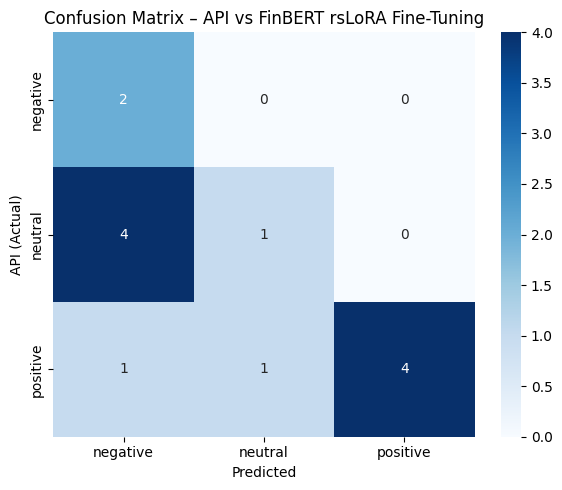

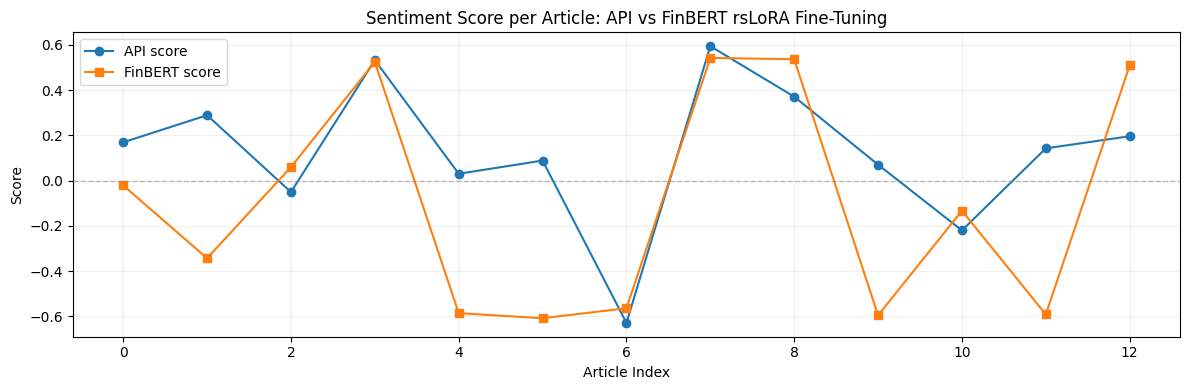


Label Agreement:     53.8%
Pearson Correlation: 0.6090  (p=0.0272)


In [ ]:
from datetime import date
import requests
from scipy.stats import pearsonr

# Reusable inference function for new text
def predict_texts(texts, model, tokenizer, temperature=2.0, max_length=128):
    """
    Inference helper with temperature scaling to soften overconfident outputs.
    Higher temperature -> smoother probability distribution -> less extreme scores.
    """
    if isinstance(texts, str):
        texts = [texts]
    device = model.device
    enc = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=max_length)
    enc = {k: v.to(device) for k, v in enc.items()}

    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits / temperature, dim=-1)  # Temperature scaling

    return probs.cpu().numpy()

# Define Universe and API params
expanded_universe = {
    "Equities_US_Broad": ["SPY", "QQQ", "DIA", "IWM"],
    "Equities_Global":   ["EFA", "EEM", "URTH"],
    "Sectors_US":        ["XLF", "XLV", "XLE", "XLK"],
    "Commodities":       ["GLD", "SLV", "USO", "DBA"],
    "Fixed_Income":      ["TLT", "AGG"],
    "Cryptocurrency":    ["BTC-USD", "ETH-USD", "BNB-USD"]
}

TICKERS = [t for group in expanded_universe.values() for t in group]

ALPHAVANTAGE_KEY = "your_api_key_here"  # ← Reemplaza con tu clave de API de Alpha Vantage
END_DATE   = date.today().isoformat()
START_DATE = (date.today() - pd.Timedelta(weeks=1)).isoformat()
LABELS     = ["negative", "neutral", "positive"]

def normalize_label(label):
    label = label.lower()
    if "positive" in label or "bullish" in label: return "positive"
    if "negative" in label or "bearish" in label: return "negative"
    return "neutral"

# Fetch Data
rows = []
print("Fetching live news from Alpha Vantage...")
for ticker in TICKERS:
    params = {
        "function": "NEWS_SENTIMENT",
        "tickers":  ticker,              # ← un solo ticker
        "time_from": START_DATE.replace("-","") + "T0000",
        "time_to":   END_DATE.replace("-","")   + "T2359",
        "limit": 200, "apikey": ALPHAVANTAGE_KEY,
    }
    try:
        response = requests.get("https://www.alphavantage.co/query", params=params, timeout=15).json()

        # Detecta rate limit antes de procesar
        if "Information" in response or "Note" in response:
            print(f"  ⚠️  Rate limit alcanzado en {ticker}, parando.")
            break

        feed = response.get("feed", [])
        for a in feed:
            rows.append({
                "ticker":   ticker,
                "date":     a.get("time_published", "")[:10],
                "title":    a.get("title", ""),
                "text":     f"{a.get('title','')}. {a.get('summary','')}".strip(),
                "url":      a.get("url", ""),
                "av_label": normalize_label(a.get("overall_sentiment_label", "Neutral")),
                "av_score": float(a.get("overall_sentiment_score", 0.0) or 0.0),
            })
        print(f"  {ticker}: {len(feed)} artículos")

    except Exception as e:
        print(f"  Error {ticker}: {e}")

df_api = pd.DataFrame(rows).drop_duplicates(subset=["text"]).reset_index(drop=True)

# Generate Predictions
api_probs = predict_texts(df_api["text"].tolist(), model, tokenizer)
df_api["finbert_label"] = [LABELS[p.argmax()] for p in api_probs]
df_api["finbert_score"] = (api_probs * np.array([-1, 0, 1])).sum(axis=1)

# Display Styled Comparison
pd.set_option("display.max_colwidth", None)

def color_label(val, av_series):
    colors = []
    for i, v in enumerate(val):
        match = v == av_series.iloc[i]
        c = "color: #155724; font-weight: bold" if match else "color: #721c24; font-weight: bold"
        colors.append(c)
    return colors

display(
    df_api[["ticker", "date", "text",
            "av_label", "av_score",
            "finbert_label", "finbert_score"]]
    .head(15)
    .style
    .apply(lambda s: color_label(s, df_api["av_label"]), subset=["finbert_label"])
    .format({"av_score": "{:.3f}", "finbert_score": "{:.3f}"})
    .set_caption("finbert_label en verde si coincide con av_label, rojo si discrepa")
)

# Plot Confusion Matrix
cm_api = confusion_matrix(df_api["av_label"], df_api["finbert_label"], labels=LABELS)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_api, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS)
plt.title("Confusion Matrix – API vs FinBERT rsLoRA Fine-Tuning")
plt.ylabel("API (Actual)"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_av_vs_finbert.png", dpi=150)
plt.show()

# Plot Score Comparison
plt.figure(figsize=(12, 4))
plt.plot(df_api.index, df_api["av_score"],      marker="o", linewidth=1.5, label="API score")
plt.plot(df_api.index, df_api["finbert_score"], marker="s", linewidth=1.5, label="FinBERT score")
plt.axhline(0, linestyle="--", linewidth=1, color="gray", alpha=0.5)
plt.title("Sentiment Score per Article: API vs FinBERT rsLoRA Fine-Tuning")
plt.xlabel("Article Index"); plt.ylabel("Score")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig("score_comparison.png", dpi=150)
plt.show()

# Metrics
agreement = (df_api["av_label"] == df_api["finbert_label"]).mean() * 100
r, p = pearsonr(df_api["av_score"], df_api["finbert_score"])
print(f"\nLabel Agreement:     {agreement:.1f}%")
print(f"Pearson Correlation: {r:.4f}  (p={p:.4f})")

## 6. Storage Efficiency & Model Serialization

One of the greatest benefits of PEFT is storage efficiency. Instead of saving a massive 400MB+ model, we only save the tiny LoRA adapter weights (which merge with the base model upon inference). Let's save the model and measure its disk footprint.

In [8]:
# Save the fine-tuned rsLoRA adapters
SAVE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "models", "finbert_rslora_finetuned"))
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Model and tokenizer saved successfully to: {SAVE_DIR}")

# Calculate the disk footprint of the saved adapters
model_size = sum(
    os.path.getsize(os.path.join(SAVE_DIR, f))
    for f in os.listdir(SAVE_DIR) if os.path.isfile(os.path.join(SAVE_DIR, f))
) / (1024 ** 2)

print(f"\nModel size on disk: {model_size:.3f} MB")

Model and tokenizer saved successfully to: /kaggle/models/finbert_rslora_finetuned

Model size on disk: 10.937 MB


In [9]:
import os, shutil

# Kaggle's writable output directory
SAVE_DIR = "/kaggle/working/finbert_rslora_finetuned"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save adapter weights + config (PEFT-aware)
trainer.save_model(SAVE_DIR)          # saves adapter_model.safetensors + adapter_config.json
tokenizer.save_pretrained(SAVE_DIR)   # saves tokenizer files

# Verify size
size_mb = sum(
    os.path.getsize(os.path.join(SAVE_DIR, f))
    for f in os.listdir(SAVE_DIR) if os.path.isfile(os.path.join(SAVE_DIR, f))
) / (1024 ** 2)
print(f"Saved to {SAVE_DIR}  ({size_mb:.2f} MB)")
print("Files:", os.listdir(SAVE_DIR))

# Optional: zip it for easy download
shutil.make_archive("/kaggle/working/finbert_rslora_finetuned", "zip", SAVE_DIR)
print("ZIP created at /kaggle/working/finbert_rslora_finetuned.zip")

Saved to /kaggle/working/finbert_rslora_finetuned  (10.94 MB)
Files: ['training_args.bin', 'tokenizer.json', 'tokenizer_config.json', 'adapter_model.safetensors', 'adapter_config.json', 'README.md']
ZIP created at /kaggle/working/finbert_rslora_finetuned.zip


In [10]:
import os

# List everything in /kaggle/working
for f in sorted(os.listdir("/kaggle/working")):
    full = os.path.join("/kaggle/working", f)
    if os.path.isfile(full):
        size_mb = os.path.getsize(full) / (1024**2)
        print(f"[FILE] {f}  ({size_mb:.2f} MB)")
    else:
        print(f"[DIR ] {f}/")

[DIR ] .virtual_documents/
[FILE] =1.1.0  (0.01 MB)
[FILE] confusion_matrix_av_vs_finbert.png  (0.04 MB)
[FILE] confusion_matrix_rslora.png  (0.04 MB)
[DIR ] finbert_rslora_finetuned/
[FILE] finbert_rslora_finetuned.zip  (9.69 MB)
[FILE] score_comparison.png  (0.10 MB)
